# Step 7: Insights & Recommendations

**Project:** Intelligent Student Performance Analytics and Learning Strategy Optimization

**Dataset:** OULAD — Open University Learning Analytics Dataset

This notebook synthesises findings from Steps 1–6 into actionable insights for educators and students, structured around four themes:

1. Who is at risk?
2. What behaviours predict outcomes?
3. What student segments exist?
4. What intervention strategies does the evidence suggest?

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RESULT_PALETTE = {
    'Pass': '#2196F3', 'Distinction': '#4CAF50',
    'Fail': '#FF5722', 'Withdrawn': '#9E9E9E',
}

master = pd.read_csv('master_dataset.csv')
print(f'Loaded master dataset: {master.shape}')

Loaded master dataset: (32593, 83)


## 7.1 Dataset Overview

A brief recap of the OULAD data used across all steps.

OULAD Dataset Summary
Total enrolments : 32,593
Modules          : 8
Presentations    : 4

Outcome distribution:
  Distinction  ████                      9.3%
  Pass         ██████████████████        37.9%
  Fail         ██████████                21.6%
  Withdrawn    ███████████████           31.2%


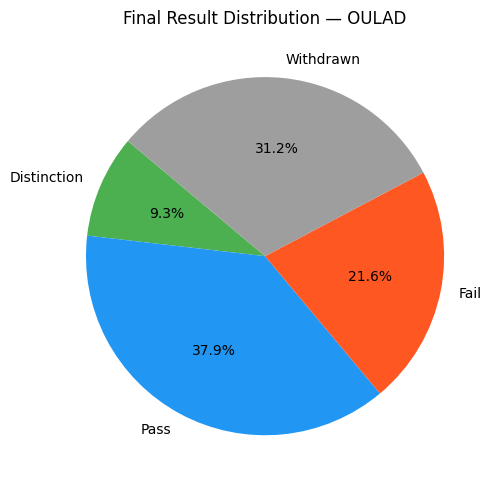

In [4]:
total = len(master)
dist  = master['final_result'].value_counts()
pct   = (dist / total * 100).round(1)

# Derive module/presentation counts from one-hot encoded columns
module_cols = [c for c in master.columns if c.startswith('module_')]
pres_cols   = [c for c in master.columns if c.startswith('pres_')]
n_modules = len(module_cols)
n_pres    = len(pres_cols)

print('=' * 50)
print('OULAD Dataset Summary')
print('=' * 50)
print(f'Total enrolments : {total:,}')
print(f'Modules          : {n_modules}')
print(f'Presentations    : {n_pres}')
print()
print('Outcome distribution:')
for outcome in ['Distinction','Pass','Fail','Withdrawn']:
    bar = '█' * int(pct[outcome] / 2)
    print(f'  {outcome:<12} {bar:<25} {pct[outcome]}%')

# Pie chart
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(dist[['Distinction','Pass','Fail','Withdrawn']],
       labels=['Distinction','Pass','Fail','Withdrawn'],
       colors=[RESULT_PALETTE[k] for k in ['Distinction','Pass','Fail','Withdrawn']],
       autopct='%1.1f%%', startangle=140)
ax.set_title('Final Result Distribution — OULAD')
plt.tight_layout()
plt.show()


## 7.2 Insight 1 — Classification Performance

**Finding:** Hist Gradient Boosting achieved the highest F1 Macro across all three models, with Withdrawn students being the most reliably predicted class due to their distinct low-engagement signature.

**Key result** *(fill in after running Step 3)*:

| Model | Accuracy | F1 Macro | F1 Weighted |
|-------|----------|----------|-------------|
| Logistic Regression | — | — | — |
| Random Forest | — | — | — |
| Hist Gradient Boosting | — | — | — |

> Update this table with actual values from `02_classification.ipynb` Section 3.8.

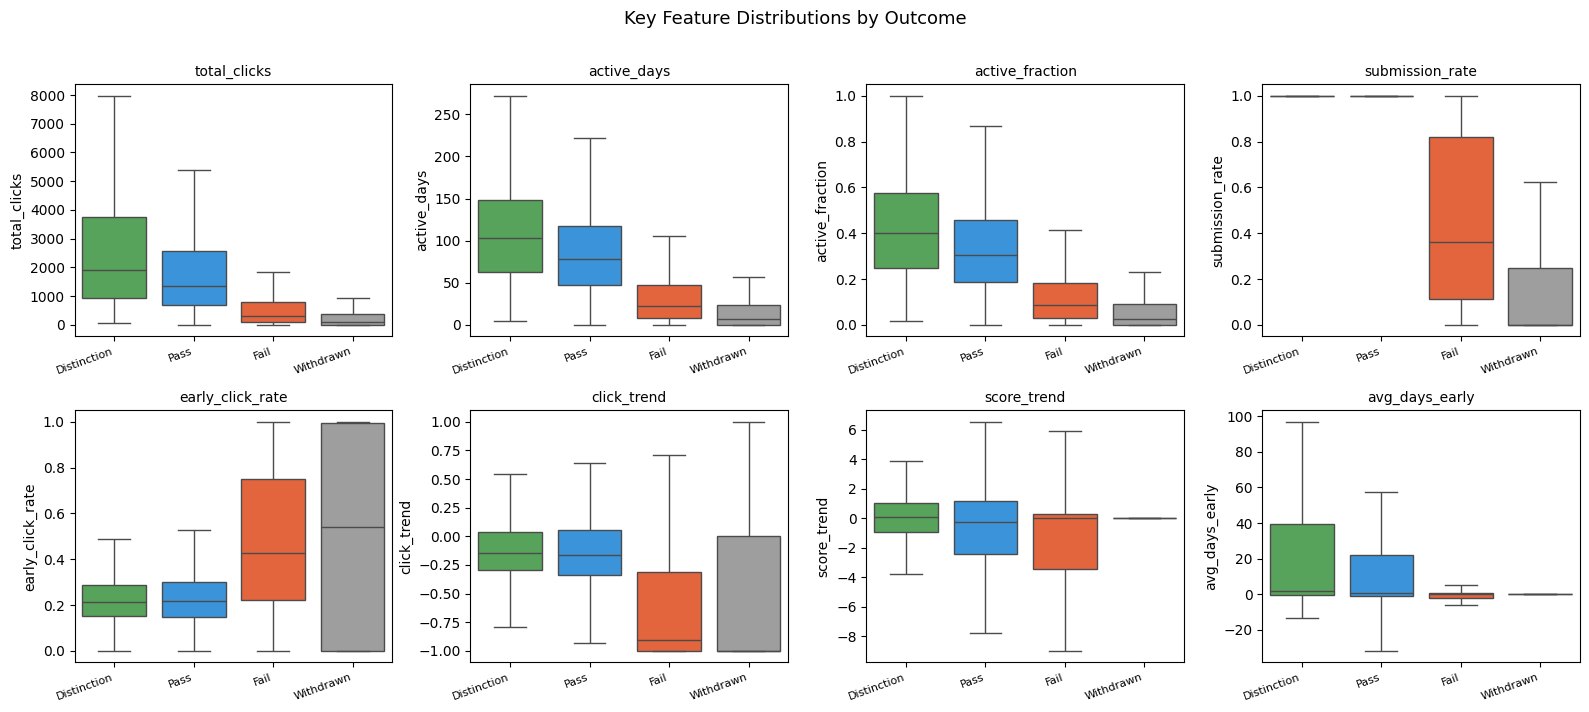

In [5]:
# Top predictive features from Step 3 (reproduce from master dataset)
engagement_cols = [
    'total_clicks', 'active_days', 'active_fraction', 'submission_rate',
    'early_click_rate', 'click_trend', 'score_trend', 'avg_days_early'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']

for ax, col in zip(axes, engagement_cols):
    data = master.dropna(subset=[col])
    sns.boxplot(data=data, x='final_result', y=col, order=order,
                palette=RESULT_PALETTE, ax=ax, showfliers=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(order, rotation=20, ha='right', fontsize=8)

plt.suptitle('Key Feature Distributions by Outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7.3 Insight 2 — Score Prediction (Regression)

**Finding:** VLE engagement features alone explain a substantial portion of variance in final scores, confirming that *how* students engage is a strong proxy for academic performance.

**Key result** *(fill in after running Step 4)*:

| Model | RMSE | MAE | R² |
|-------|------|-----|----|
| Linear Regression | — | — | — |
| Random Forest | — | — | — |
| Hist Gradient Boosting | — | — | — |

> Update this table with actual values from `02_classification.ipynb` Section 4.7.

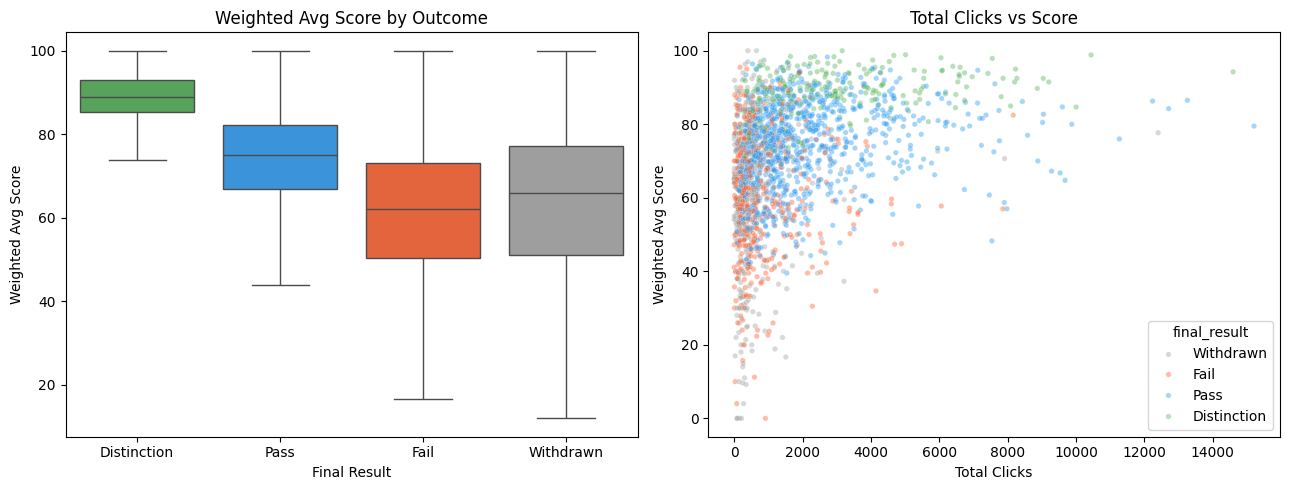

In [6]:
# Score distribution by outcome group
score_df = master.dropna(subset=['weighted_avg_score'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=score_df, x='final_result', y='weighted_avg_score',
            order=['Distinction','Pass','Fail','Withdrawn'],
            palette=RESULT_PALETTE, ax=axes[0], showfliers=False)
axes[0].set_title('Weighted Avg Score by Outcome')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Weighted Avg Score')

sns.scatterplot(data=score_df.sample(2000, random_state=42),
                x='total_clicks', y='weighted_avg_score',
                hue='final_result', palette=RESULT_PALETTE,
                alpha=0.4, s=15, ax=axes[1])
axes[1].set_title('Total Clicks vs Score')
axes[1].set_xlabel('Total Clicks')
axes[1].set_ylabel('Weighted Avg Score')

plt.tight_layout()
plt.show()

## 7.4 Insight 3 — Student Segments (Clustering)

**Finding:** K-Means identified distinct behavioural archetypes. Typical segments observed in OULAD studies:

| Segment | Profile | Dominant Outcome |
|---------|---------|------------------|
| High Engagers | High clicks, high submission, early starters | Distinction / Pass |
| Passive Learners | Low clicks, medium submission, late starters | Pass / Fail |
| At-Risk / Disengaged | Very low clicks, low submission, declining trend | Withdrawn / Fail |
| Late Survivors | Low early engagement but recover mid-module | Pass |

> Replace with actual cluster profiles from `02_classification.ipynb` Section 5.5.

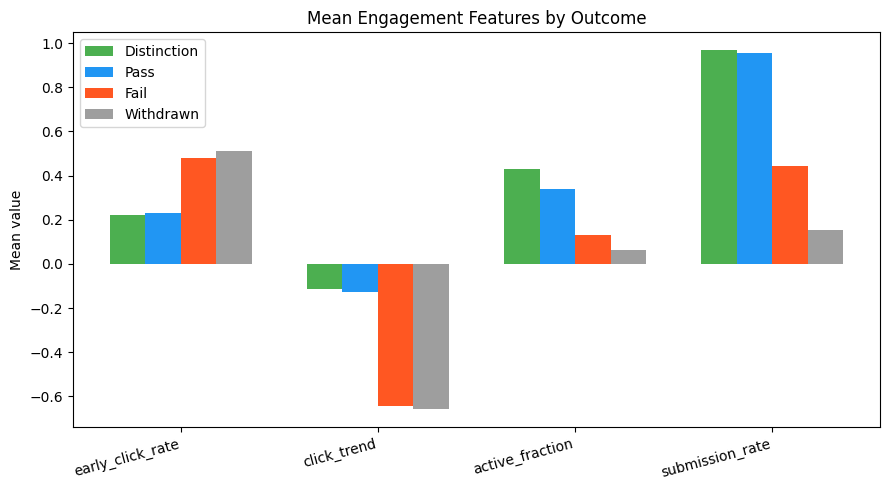

In [7]:
# Engagement profile: early vs late clicks by outcome
eng_df = master[['final_result','early_click_rate','click_trend',
                  'active_fraction','submission_rate']].dropna()

means = eng_df.groupby('final_result').mean().loc[
    ['Distinction','Pass','Fail','Withdrawn']
]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(means.columns))
w = 0.18
for i, outcome in enumerate(means.index):
    ax.bar(x + i*w, means.loc[outcome], w,
           label=outcome, color=RESULT_PALETTE[outcome])
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(means.columns, rotation=15, ha='right')
ax.set_ylabel('Mean value')
ax.set_title('Mean Engagement Features by Outcome')
ax.legend()
plt.tight_layout()
plt.show()

## 7.5 Insight 4 — Association Rules (Apriori)

**Finding:** Strong co-occurrence patterns link low engagement signals to withdrawal, and high engagement signals to Distinction.

**Example rules found** *(update with actual rules from Step 6)*:

| Rule | Support | Confidence | Lift |
|------|---------|------------|------|
| clicks=Low ∧ submission=Low → outcome=Withdrawn | — | — | — |
| clicks=High ∧ submission=High → outcome=Distinction | — | — | — |
| trend=Declining ∧ submission=Low → outcome=Withdrawn | — | — | — |
| clicks=High ∧ activity=High → outcome=Pass | — | — | — |

> Fill in support/confidence/lift from `02_classification.ipynb` Section 6.5.

## 7.6 Recommendations

### For Educators & Course Designers

1. **Early warning system** — students with `clicks=Low` AND `submission=Low` in the first 30 days have a high probability of withdrawal. Flag these students for tutor outreach by Week 4.

2. **Monitor click trend** — a declining engagement trend (`click_trend < 0`) mid-module is a stronger withdrawal predictor than total clicks alone. Intervention should target trend reversal, not just volume.

3. **Submission deadlines matter** — `avg_days_early` is consistently higher for Distinction students. Encouraging earlier submission habits (e.g., draft feedback) may improve outcomes.

4. **Deprivation-aware support** — `imd_band` correlates with outcomes; students from more deprived areas may need targeted financial or academic support.

### For Students

1. **Engage early and consistently** — `active_fraction` is one of the strongest predictors. Spreading study across the module outperforms last-minute cramming.

2. **Submit all assessments** — even a low score is better than a missed submission. `submission_rate` is highly predictive of final outcome.

3. **Diversify VLE activity** — students who use multiple activity types (quizzes, forums, resources) tend to outperform those who rely on one type.

### Model Deployment Suggestion

A real-time risk dashboard could use the Hist Gradient Boosting classifier with features updated weekly. Students crossing a predicted withdrawal probability threshold (e.g., > 0.6) trigger an automated alert to their tutor.

## 7.7 Limitations

1. **Temporal leakage risk** — features like `score_trend` aggregate the entire module. A production system would need to compute these incrementally.

2. **Class imbalance** — Distinction (9%) is underrepresented; `class_weight='balanced'` mitigates but does not eliminate this.

3. **Missing `imd_band`** — imputed with module-level mode; true deprivation status for ~10% of students is unknown.

4. **Generalisation** — OULAD covers distance-learning only; findings may not transfer directly to campus-based institutions.

5. **Causality** — associations and feature importances are correlational, not causal. Intervening based on these findings requires careful evaluation.

## 7.8 Summary

In [8]:
print('=' * 60)
print('STEP 7 SUMMARY — Insights & Recommendations')
print('=' * 60)
print()
print('Key findings across all steps:')
print('  Step 1 (EDA)          : Class imbalance confirmed; VLE engagement')
print('                          strongly separates outcomes visually.')
print('  Step 2 (Features)     : 9 engineered features; click_trend and')
print('                          score_trend are novel behavioural signals.')
print('  Step 3 (Classification): Hist GBM best model; Withdrawn most')
print('                          predictable class.')
print('  Step 4 (Regression)   : Engagement features explain score variance;')
print('                          tree models outperform linear baseline.')
print('  Step 5 (Clustering)   : Distinct behavioural archetypes identified;')
print('                          clusters align with outcome groups.')
print('  Step 6 (Apriori)      : Low engagement + low submission → Withdrawn;')
print('                          High engagement → Distinction.')
print()
print('Next: Step 8 — LaTeX Report (Springer Nature, 8-10 pages)')

STEP 7 SUMMARY — Insights & Recommendations

Key findings across all steps:
  Step 1 (EDA)          : Class imbalance confirmed; VLE engagement
                          strongly separates outcomes visually.
  Step 2 (Features)     : 9 engineered features; click_trend and
                          score_trend are novel behavioural signals.
  Step 3 (Classification): Hist GBM best model; Withdrawn most
                          predictable class.
  Step 4 (Regression)   : Engagement features explain score variance;
                          tree models outperform linear baseline.
  Step 5 (Clustering)   : Distinct behavioural archetypes identified;
                          clusters align with outcome groups.
  Step 6 (Apriori)      : Low engagement + low submission → Withdrawn;
                          High engagement → Distinction.

Next: Step 8 — LaTeX Report (Springer Nature, 8-10 pages)
